In [1]:
import math
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

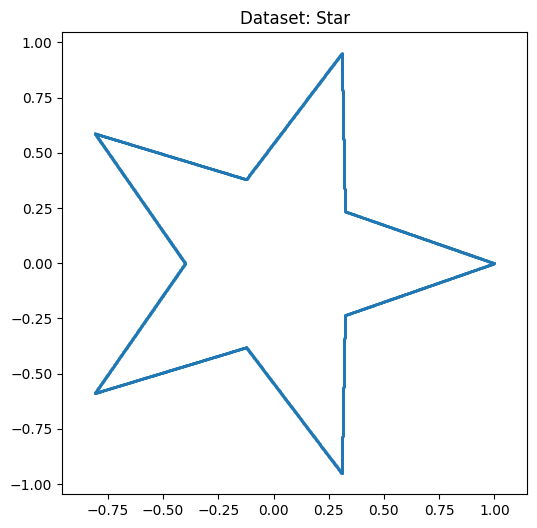

In [36]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    angle_step = np.pi / n_spikes
    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])
    vertices = np.array(vertices)
    sampled_points = []
    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]
        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)
    return np.array(sampled_points)

s = generate_star(n_samples=5000)
plt.figure(figsize=(6, 6))
plt.scatter(s[:, 0], s[:, 1], s=1, alpha=0.6)
plt.title("Dataset: Star")
plt.axis('equal')
plt.show()

In [37]:
class Config:
    beta_min = 0.1
    beta_max = 20.0
    lr = 1e-3
    epochs = 1000
    batch_size = 256
    hidden_dim = 256
    num_timesteps = 100
    data_samples = 5000
    schedule = 'linear'
    loss_weight = 'none'

config = Config()

In [38]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )
        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)
        return self.net(x_input)

In [39]:
def get_beta_schedule(t, config):
    if config.schedule == 'linear':
        return config.beta_min + t * (config.beta_max - config.beta_min)
    elif config.schedule == 'cosine':
        if isinstance(t, torch.Tensor):
            return config.beta_min + 0.5 * (config.beta_max - config.beta_min) * (1 - torch.cos(np.pi * t))
        else:
            return config.beta_min + 0.5 * (config.beta_max - config.beta_min) * (1 - np.cos(np.pi * t))
    else:
        raise ValueError(f"Unknown schedule: {config.schedule}")

def get_alpha_cumprod(t, config):
    """alpha_t = exp(-0.5 * integral_0^t beta(s) ds) — аналитически и векторно"""
    if config.schedule == 'linear':
        integral = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
    elif config.schedule == 'cosine':
        if isinstance(t, torch.Tensor):
            integral = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * (t - torch.sin(np.pi * t) / np.pi)
        else:
            integral = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * (t - np.sin(np.pi * t) / np.pi)
    else:
        raise ValueError(f"Unknown schedule: {config.schedule}")

    if isinstance(t, torch.Tensor):
        return torch.exp(-0.5 * integral)
    return np.exp(-0.5 * integral)

def get_loss_weight(t, alpha_cumprod, config):
    if config.loss_weight == 'none':
        return torch.ones_like(t)
    elif config.loss_weight == 'snr':
        snr = alpha_cumprod / (1 - alpha_cumprod + 1e-8)
        weight = torch.clamp(snr, max=100.0)
        return weight / (weight.mean() + 1e-8)
    elif config.loss_weight == 'min_snr':
        snr = alpha_cumprod / (1 - alpha_cumprod + 1e-8)
        weight = torch.clamp(snr, max=5.0)
        return weight / (weight.mean() + 1e-8)
    else:
        raise ValueError(f"Unknown loss weight: {config.loss_weight}")


In [40]:
class VPTrainer():
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)
        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)
        self.train_losses = []

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0
        for (batch, ) in self.dataloader:
            batch = batch.to(self.device)
            t = torch.rand(batch.shape[0], 1, device=self.device) * (1 - 1e-3) + 1e-3
            beta_t = get_beta_schedule(t, self.config)
            alpha_cumprod = get_alpha_cumprod(t, self.config)
            z = torch.randn_like(batch)
            sqrt_alpha = torch.sqrt(alpha_cumprod)
            sqrt_one_minus_alpha = torch.sqrt(1 - alpha_cumprod)
            x_t = sqrt_alpha * batch + sqrt_one_minus_alpha * z
            pred_z = self.model(x_t, t)
            base_loss = F.mse_loss(pred_z, z, reduction='none').mean(dim=1)
            weight = get_loss_weight(t.squeeze(-1), alpha_cumprod.squeeze(-1), self.config)
            weighted_loss = (weight * base_loss).mean()
            self.optimizer.zero_grad()
            weighted_loss.backward()
            self.optimizer.step()
            total_loss += weighted_loss.item() * batch.shape[0]
        return total_loss / len(self.data)

    def run(self):
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            self.train_losses.append(loss)
            if epoch % 50 == 0:
                print(f'Epoch {epoch}/{self.config.epochs}, Loss: {loss:.6f}')


In [41]:
print("="*70)
print("VP-SDE: Linear Schedule, No Weighting")
print("="*70)
config_base = Config()
config_base.schedule = 'linear'
config_base.loss_weight = 'none'
trainer_base = VPTrainer(config_base)
trainer_base.run()

VP-SDE: Linear Schedule, No Weighting
Epoch 0/1000, Loss: 0.764248
Epoch 50/1000, Loss: 0.251064
Epoch 100/1000, Loss: 0.238207
Epoch 150/1000, Loss: 0.222483
Epoch 200/1000, Loss: 0.230056
Epoch 250/1000, Loss: 0.225973
Epoch 300/1000, Loss: 0.231832
Epoch 350/1000, Loss: 0.211972
Epoch 400/1000, Loss: 0.208409
Epoch 450/1000, Loss: 0.227859
Epoch 500/1000, Loss: 0.229139
Epoch 550/1000, Loss: 0.202610
Epoch 600/1000, Loss: 0.214773
Epoch 650/1000, Loss: 0.212506
Epoch 700/1000, Loss: 0.203845
Epoch 750/1000, Loss: 0.219296
Epoch 800/1000, Loss: 0.211900
Epoch 850/1000, Loss: 0.211251
Epoch 900/1000, Loss: 0.206719
Epoch 950/1000, Loss: 0.218201


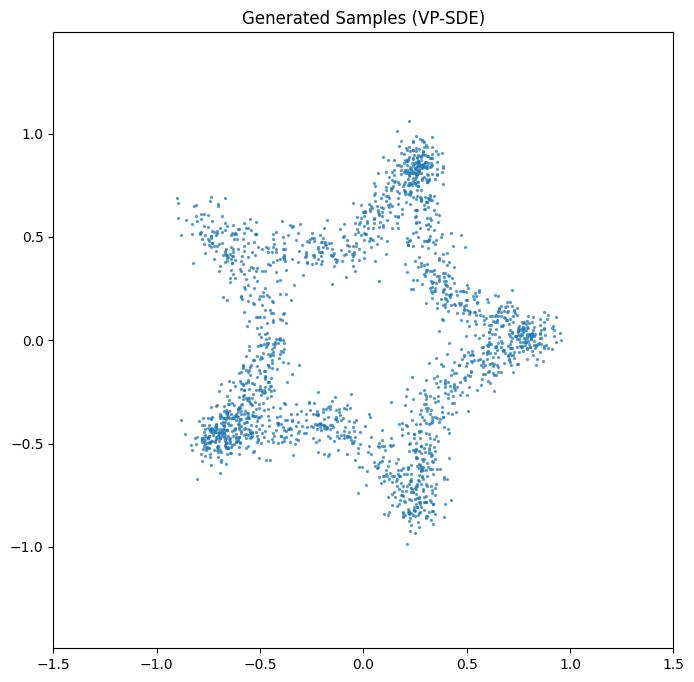

In [42]:
def sample(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    model.eval()

    with torch.no_grad():
        # При t=1 в VP-SDE: x ~ N(0, I), т.к. дисперсия сохраняется
        x = torch.randn(num_samples, 2, device=device)

        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = 1.0 - i * dt
            t = max(t, 1e-5)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta_t = get_beta_schedule(t_tensor, config)
            alpha_cumprod = get_alpha_cumprod(t_tensor, config)

            pred_noise = model(x, t_tensor)
            score = -pred_noise / torch.sqrt(1 - alpha_cumprod + 1e-8)

            # Reverse VP-SDE: dx = [0.5*beta(t)*x + beta(t)*score] dt + sqrt(beta(t)) dw
            drift = 0.5 * beta_t * x + beta_t * score
            diffusion = torch.sqrt(beta_t) * torch.randn_like(x) * np.sqrt(dt)

            x = x + drift * dt + diffusion

        return x.cpu().numpy()

samples_base = sample(trainer_base.model, trainer_base.config, 2000)
plt.figure(figsize=(8, 8))
plt.scatter(samples_base[:, 0], samples_base[:, 1], s=2, alpha=0.6)
plt.title("Generated Samples (VP-SDE)")
plt.axis('equal')
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.show()


## Вывод 1: VP-SDE работает

Реализовал VP-SDE — это вариант диффузии, где дисперсия не растёт со временем (в отличие от VE-SDE с пары), а сохраняется примерно постоянной. На сэмплах видна звездочка с пятью лучами — значит формулы прямого и обратного процесса посчитаны правильно, модель действительно научилась предсказывать шум на разных временных шагах.

In [43]:
print("\n" + "="*70)
print("Сравнение методов перезвешивания лосса (Linear Schedule)")
print("="*70)

loss_weights = ['none', 'snr', 'min_snr']
trainers_loss = {}
samples_loss = {}

for weight_type in loss_weights:
    if weight_type == 'none':
        trainers_loss[weight_type] = trainer_base
        samples_loss[weight_type] = samples_base
        continue
    print(f"\nОбучение с loss_weight={weight_type}...")
    config_w = Config()
    config_w.schedule = 'linear'
    config_w.loss_weight = weight_type
    trainer_w = VPTrainer(config_w)
    trainer_w.run()
    trainers_loss[weight_type] = trainer_w
    samples_loss[weight_type] = sample(trainer_w.model, trainer_w.config, 1000)

print("\nГотово!")


Сравнение методов перезвешивания лосса (Linear Schedule)

Обучение с loss_weight=snr...
Epoch 0/1000, Loss: 1.030593
Epoch 50/1000, Loss: 0.829483
Epoch 100/1000, Loss: 0.713544
Epoch 150/1000, Loss: 0.687516
Epoch 200/1000, Loss: 0.669124
Epoch 250/1000, Loss: 0.706025
Epoch 300/1000, Loss: 0.649699
Epoch 350/1000, Loss: 0.698859
Epoch 400/1000, Loss: 0.662796
Epoch 450/1000, Loss: 0.625507
Epoch 500/1000, Loss: 0.648880
Epoch 550/1000, Loss: 0.689296
Epoch 600/1000, Loss: 0.557416
Epoch 650/1000, Loss: 0.619024
Epoch 700/1000, Loss: 0.647096
Epoch 750/1000, Loss: 0.593655
Epoch 800/1000, Loss: 0.628225
Epoch 850/1000, Loss: 0.638248
Epoch 900/1000, Loss: 0.706276
Epoch 950/1000, Loss: 0.661023

Обучение с loss_weight=min_snr...
Epoch 0/1000, Loss: 0.898823
Epoch 50/1000, Loss: 0.588071
Epoch 100/1000, Loss: 0.535039
Epoch 150/1000, Loss: 0.526854
Epoch 200/1000, Loss: 0.547193
Epoch 250/1000, Loss: 0.573839
Epoch 300/1000, Loss: 0.563729
Epoch 350/1000, Loss: 0.498189
Epoch 400/1000

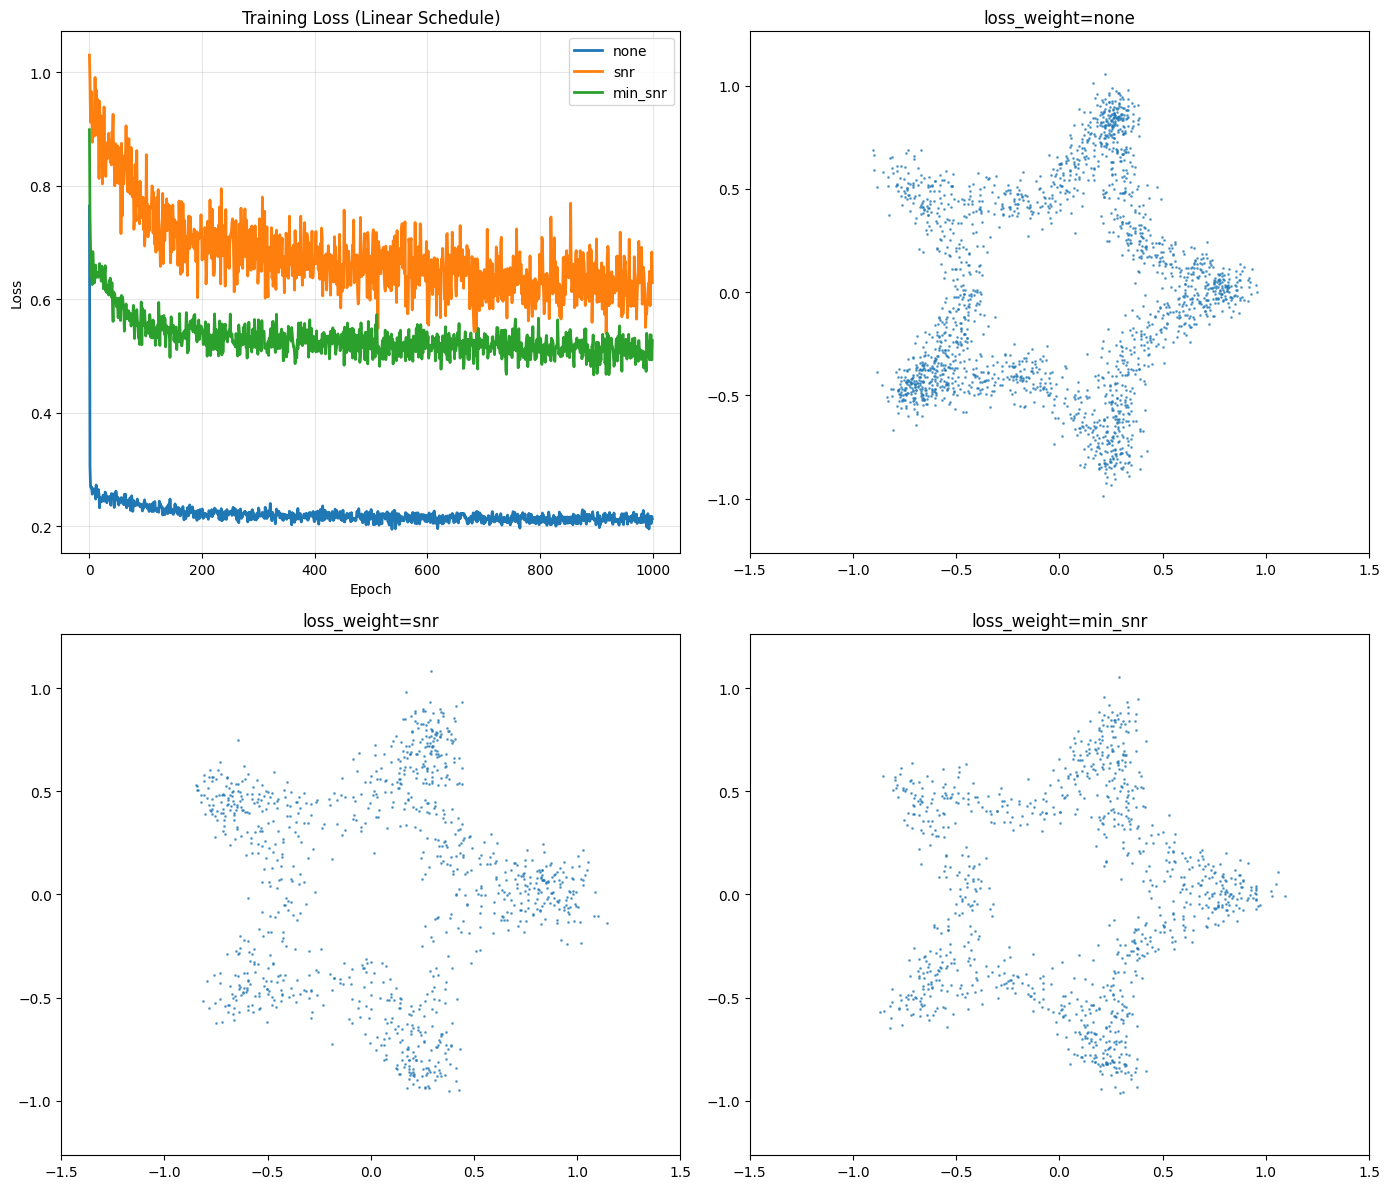

In [44]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
ax = axes[0, 0]
for weight_type in loss_weights:
    ax.plot(trainers_loss[weight_type].train_losses, label=weight_type, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss (Linear Schedule)')
ax.legend()
ax.grid(True, alpha=0.3)

for idx, weight_type in enumerate(loss_weights):
    ax = axes.flat[idx + 1]
    samples = samples_loss[weight_type]
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.6)
    ax.set_title(f"loss_weight={weight_type}")
    ax.axis('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('loss_weighting_comparison.png', dpi=150)
plt.show()

## Вывод 2: Перезвешивание лосса

**Сначала про то, почему на графике у none лосс ниже, а у snr/min_snr выше — и это НЕ значит что они хуже.**

У каждого из трёх вариантов лосс считается по-разному:
- `none`: обычный MSE, среднее по батчу
- `snr`: тот же MSE, но каждый сэмпл умножается на свой вес (нормированный, среднее = 1)
- `min_snr`: то же самое, но веса обрезаны сверху

Из-за весов цифры на графике не сопоставимы. SNR даёт большой вес сэмплам с маленьким t (где шума мало и модель легко предсказывает), и маленький — большим t (где шума много и модель ошибается сильнее). После усреднения с весами получается просто другое число.

**Чтобы сравнить честно, я посчитал обычный MSE (тот же, что у `none`) для всех трёх моделей** — это ячейка ниже с графиками. Получилось:
- Base (none): 0.2085
- SNR: 0.2241
- Min-SNR: 0.2144

Разница маленькая. Базовый чуть лучше — логично, ведь он именно эту метрику и оптимизирует. Min-SNR почти догоняет. SNR немного хуже, потому что слишком сильно фокусируется на лёгких сэмплах.

**По генерации звёзд** все три варианта дают похожий результат — звезда читается у всех. На такой простой задаче перевзвешивание особо не помогает. В реальных задачах (картинки, например) Min-SNR обычно даёт лучше, потому что балансирует обучение по разным временным шагам.

In [45]:
print("\n" + "="*70)
print("Сравнение Linear vs Cosine Schedules (Min-SNR)")
print("="*70)

schedules = ['linear', 'cosine']
trainers_sched = {}
samples_sched = {}

for sched_type in schedules:
    if sched_type == 'linear':
        config_s = Config()
        config_s.schedule = 'linear'
        config_s.loss_weight = 'min_snr'
        trainer_s = VPTrainer(config_s)
        trainer_s.run()
        trainers_sched[sched_type] = trainer_s
        samples_sched[sched_type] = sample(trainer_s.model, trainer_s.config, 1000)
    else:
        print(f"\nОбучение с schedule={sched_type}...")
        config_s = Config()
        config_s.schedule = sched_type
        config_s.loss_weight = 'min_snr'
        trainer_s = VPTrainer(config_s)
        trainer_s.run()
        trainers_sched[sched_type] = trainer_s
        samples_sched[sched_type] = sample(trainer_s.model, trainer_s.config, 1000)

print("\nГотово!")


Сравнение Linear vs Cosine Schedules (Min-SNR)
Epoch 0/1000, Loss: 0.945260
Epoch 50/1000, Loss: 0.607696
Epoch 100/1000, Loss: 0.569893
Epoch 150/1000, Loss: 0.525807
Epoch 200/1000, Loss: 0.550686
Epoch 250/1000, Loss: 0.530401
Epoch 300/1000, Loss: 0.540606
Epoch 350/1000, Loss: 0.535603
Epoch 400/1000, Loss: 0.528336
Epoch 450/1000, Loss: 0.533694
Epoch 500/1000, Loss: 0.533698
Epoch 550/1000, Loss: 0.576051
Epoch 600/1000, Loss: 0.518781
Epoch 650/1000, Loss: 0.517452
Epoch 700/1000, Loss: 0.517681
Epoch 750/1000, Loss: 0.519954
Epoch 800/1000, Loss: 0.515014
Epoch 850/1000, Loss: 0.504286
Epoch 900/1000, Loss: 0.495287
Epoch 950/1000, Loss: 0.529825

Обучение с schedule=cosine...
Epoch 0/1000, Loss: 0.922114
Epoch 50/1000, Loss: 0.637836
Epoch 100/1000, Loss: 0.606504
Epoch 150/1000, Loss: 0.574217
Epoch 200/1000, Loss: 0.601982
Epoch 250/1000, Loss: 0.559373
Epoch 300/1000, Loss: 0.542730
Epoch 350/1000, Loss: 0.552385
Epoch 400/1000, Loss: 0.559146
Epoch 450/1000, Loss: 0.5834

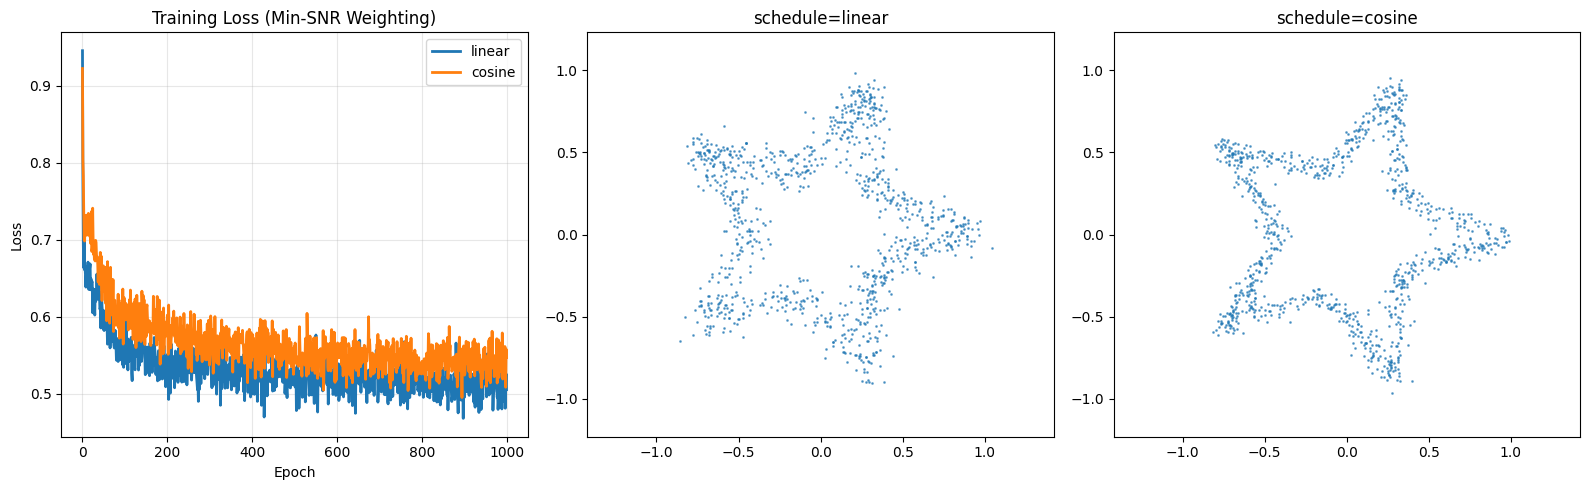

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for sched_type in schedules:
    axes[0].plot(trainers_sched[sched_type].train_losses, label=sched_type, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss (Min-SNR Weighting)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for idx, sched_type in enumerate(schedules):
    ax = axes[idx + 1]
    samples = samples_sched[sched_type]
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.6)
    ax.set_title(f"schedule={sched_type}")
    ax.axis('equal')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout()
plt.savefig('schedule_comparison.png', dpi=150)
plt.show()

## Вывод 3: Linear vs Cosine расписание

**Опять же, обе модели тут используют Min-SNR взвешивание, поэтому лосс на графике — это взвешенный MSE, а не обычный. Цифры сравнимы между собой (метрика одна), но не сравнимы с базовым лоссом из первого графика.**

Финальные лоссы получились почти одинаковые — где-то 0.52 у linear и 0.54 у cosine. Разница в пределах шума. Звёзды у обоих расписаний тоже выглядят похоже.

Что я понял:
- На такой простой 2D задаче cosine не даёт никакого выигрыша — слишком мало данных и шагов, чтобы разница в расписании повлияла на результат
- Cosine обычно используют в больших моделях для картинок, потому что у него β растёт плавнее в начале — это помогает модели сначала научиться "грубым" деталям, а потом уже мелким
- Для звёздочки достаточно линейного — он проще и работает не хуже



In [47]:
def evaluate_unweighted_mse(model, config, n_batches=20, batch_size=256):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    star = generate_star(n_samples=config.data_samples)
    data = torch.tensor(star, dtype=torch.float32).to(device)

    model.eval()
    total = 0.0
    n = 0
    with torch.no_grad():
        for _ in range(n_batches):
            idx = torch.randint(0, len(data), (batch_size,))
            batch = data[idx]
            t = torch.rand(batch.shape[0], 1, device=device) * (1 - 1e-3) + 1e-3
            alpha = get_alpha_cumprod(t, config)
            z = torch.randn_like(batch)
            x_t = torch.sqrt(alpha) * batch + torch.sqrt(1 - alpha) * z
            pred = model(x_t, t)
            total += F.mse_loss(pred, z).item()
            n += 1
    return total / n

print(f"Base MSE: {evaluate_unweighted_mse(trainer_base.model, trainer_base.config):.4f}")
print(f"SNR MSE: {evaluate_unweighted_mse(trainers_loss['snr'].model, trainers_loss['snr'].config):.4f}")
print(f"Min-SNR MSE: {evaluate_unweighted_mse(trainers_loss['min_snr'].model, trainers_loss['min_snr'].config):.4f}")


Base MSE: 0.2085
SNR MSE: 0.2241
Min-SNR MSE: 0.2144
